--- Gram Matrix (via Kernel) ---
[[25 16  1]
 [16 25  1]
 [ 1  1  4]]

--- Gram Matrix (via Feature Mapping Phi) ---
[[25. 16.  1.]
 [16. 25.  1.]
 [ 1.  1.  4.]]

Results match: True


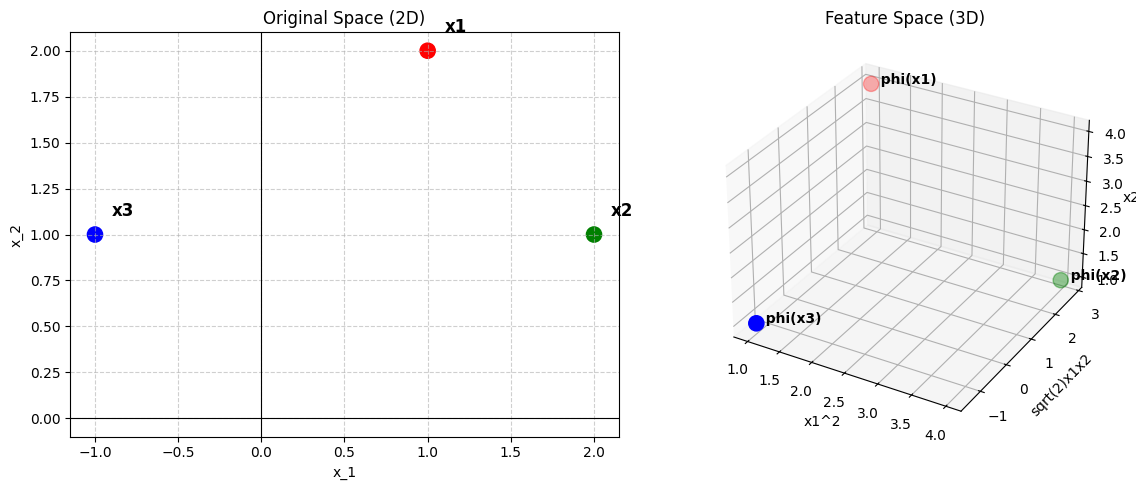

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Define the dataset in R^2
X = np.array([
    [1, 2],   # x1
    [2, 1],   # x2
    [-1, 1]   # x3
])

# 2. Method 1: Gram Matrix via Kernel function K(x, z) = (x^T z)^2
K_kernel = (X @ X.T) ** 2

# 3. Method 2: Gram Matrix via Explicit Feature Mapping phi(x) in R^3
# phi(x) = [x1^2, sqrt(2)*x1*x2, x2^2]
Phi = np.column_stack([
    X[:, 0]**2,
    np.sqrt(2) * X[:, 0] * X[:, 1],
    X[:, 1]**2
])
K_phi = Phi @ Phi.T

# Verify both methods match
print("--- Gram Matrix (via Kernel) ---")
print(K_kernel)
print("\n--- Gram Matrix (via Feature Mapping Phi) ---")
print(K_phi)
print("\nResults match:", np.allclose(K_kernel, K_phi))

# 4. Visualization: 2D Original Space vs 3D Feature Space
fig = plt.figure(figsize=(12, 5))

# 2D Plot
ax1 = fig.add_subplot(121)
ax1.scatter(X[:, 0], X[:, 1], color=['red', 'green', 'blue'], s=120)
for i, txt in enumerate(['x1', 'x2', 'x3']):
    ax1.annotate(txt, (X[i, 0] + 0.1, X[i, 1] + 0.1), fontsize=12, fontweight='bold')
ax1.set_title('Original Space (2D)')
ax1.set_xlabel('x_1')
ax1.set_ylabel('x_2')
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.axhline(0, color='black', linewidth=0.8)
ax1.axvline(0, color='black', linewidth=0.8)

# 3D Plot
ax2 = fig.add_subplot(122, projection='3d')
ax2.scatter(Phi[:, 0], Phi[:, 1], Phi[:, 2], color=['red', 'green', 'blue'], s=120)
for i, txt in enumerate(['phi(x1)', 'phi(x2)', 'phi(x3)']):
    ax2.text(Phi[i, 0], Phi[i, 1], Phi[i, 2], f"  {txt}", fontsize=10, fontweight='bold')
ax2.set_title('Feature Space (3D)')
ax2.set_xlabel('x1^2')
ax2.set_ylabel('sqrt(2)x1x2')
ax2.set_zlabel('x2^2')

plt.tight_layout()
plt.show()

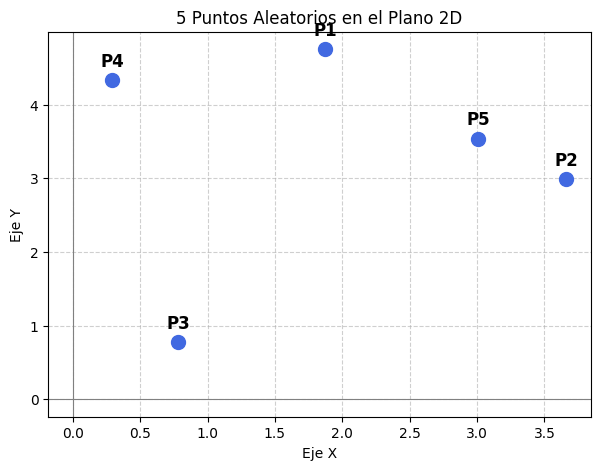

--- Matriz de Gram (Kernel Gaussiano, gamma=0.5) ---
[[1.    0.043 0.    0.262 0.252]
 [0.043 1.    0.001 0.001 0.695]
 [0.    0.001 1.    0.002 0.002]
 [0.262 0.001 0.002 1.    0.018]
 [0.252 0.695 0.002 0.018 1.   ]]


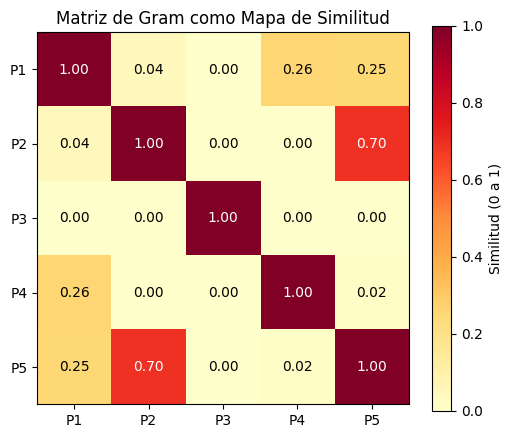

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Generamos 5 puntos aleatorios en 2D
np.random.seed(42)  # Para que los números aleatorios sean reproducibles
X = np.random.uniform(
    low=0.0, high=5.0, size=(5, 2)
)  # 5 puntos, coordenadas (x, y)
labels = [f"P{i+1}" for i in range(len(X))]  # Etiquetas: P1, P2, P3, P4, P5

# 2. Visualizamos los puntos en un gráfico 2D con sus etiquetas
plt.figure(figsize=(7, 5))
plt.scatter(X[:, 0], X[:, 1], color="royalblue", s=100, zorder=3)

for i, txt in enumerate(labels):
  # Añadimos un pequeño desfase (offset) para que el texto no tape al punto
  plt.annotate(
      txt,
      (X[i, 0], X[i, 1]),
      textcoords="offset points",
      xytext=(0, 10),
      ha="center",
      fontsize=12,
      fontweight="bold",
  )

plt.title("5 Puntos Aleatorios en el Plano 2D")
plt.xlabel("Eje X")
plt.ylabel("Eje Y")
plt.grid(True, linestyle="--", alpha=0.6)
plt.axhline(0, color="gray", linewidth=0.8)
plt.axvline(0, color="gray", linewidth=0.8)
plt.show()


# 3. Implementamos nuestro propio Kernel Gaussiano (RBF) desde cero
def kernel_gaussiano(X1, X2, gamma=1.0):
  """Calcula la matriz de Gram usando el kernel gaussiano:

  K(x_i, x_j) = exp(-gamma * ||x_i - x_j||^2)
  """
  n1 = X1.shape[0]
  n2 = X2.shape[0]
  K = np.zeros((n1, n2))

  for i in range(n1):
    for j in range(n2):
      # Calculamos la distancia euclidiana al cuadrado entre el punto i y el punto j
      dist_cuadrada = np.sum((X1[i] - X2[j]) ** 2)
      # Aplicamos la función exponencial del kernel
      K[i, j] = np.exp(-gamma * dist_cuadrada)

  return K


# 4. Calculamos la matriz de Gram con nuestra función (usando gamma = 0.5)
gamma_valor = 0.5
matriz_gram = kernel_gaussiano(X, X, gamma=gamma_valor)

# 5. Mostramos la matriz de Gram resultante de forma limpia
print(f"--- Matriz de Gram (Kernel Gaussiano, gamma={gamma_valor}) ---")
print(np.array2string(matriz_gram, precision=3, suppress_small=True))

# 6. Visualizamos la matriz de Gram como un mapa de calor (Heatmap)
plt.figure(figsize=(6, 5))
cax = plt.imshow(matriz_gram, cmap="YlOrRd", vmin=0, vmax=1)
plt.colorbar(cax, label="Similitud (0 a 1)")
plt.xticks(range(len(X)), labels)
plt.yticks(range(len(X)), labels)
plt.title("Matriz de Gram como Mapa de Similitud")

# Escribimos los valores numéricos dentro de cada celda del mapa de calor
for i in range(len(X)):
  for j in range(len(X)):
    plt.text(
        j,
        i,
        f"{matriz_gram[i, j]:.2f}",
        ha="center",
        va="center",
        color="black" if matriz_gram[i, j] < 0.6 else "white",
    )

plt.show()